Yeh din Month 4 ke ML training ke liye bahut important hai — agar dataset imbalanced hai (jaise 85% non-churned, 15% churned), to model bina kuch "seekhe" bhi sirf majority class predict karke high accuracy dikha sakta hai, jo asal mein useless model hota hai.

1. Setup:

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('../data/processed/customer_churn_labeled.csv')

2. Exact counts aur percentage nikaalo:

In [2]:
churn_counts = df['Churned'].value_counts()
churn_pct = df['Churned'].value_counts(normalize=True) * 100

print("Counts:\n", churn_counts)
print("\nPercentage:\n", churn_pct.round(2))

Counts:
 Churned
1    2987
0    2894
Name: count, dtype: int64

Percentage:
 Churned
1    50.79
0    49.21
Name: proportion, dtype: float64


3. Bar chart se imbalance dikhana:

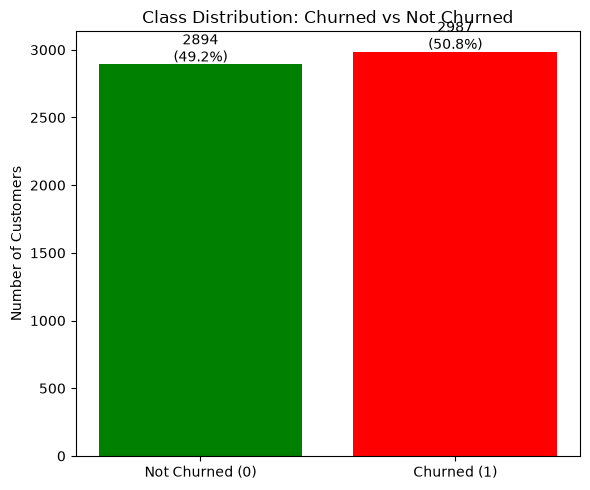

In [4]:
fig, ax = plt.subplots(figsize=(6, 5))
bars = ax.bar(['Not Churned (0)', 'Churned (1)'], churn_counts.sort_index().values, color=['green', 'red'])
ax.set_ylabel('Number of Customers')
ax.set_title('Class Distribution: Churned vs Not Churned')

for bar, pct in zip(bars, churn_pct.sort_index().values):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + 20, f'{int(height)}\n({pct:.1f}%)', ha='center')
plt.tight_layout()
plt.savefig('../reports/class_imbalance_bar.png', dpi=150)
plt.show()

4. Pie chart se bhi dikhana (dono formats README mein use ho sakte hain):

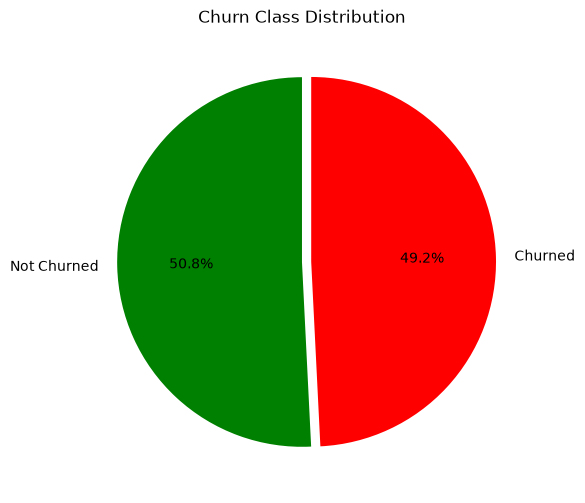

In [5]:
plt.figure(figsize=(6, 6))
plt.pie(churn_counts, labels=['Not Churned', 'Churned'], autopct='%1.1f%%', 
        colors=['green', 'red'], startangle=90, explode=(0, 0.05))
plt.title('Churn Class Distribution')
plt.savefig('../reports/class_imbalance_pie.png', dpi=150)
plt.show()

5. Imbalance Ratio calculate karo (standard metric, interview mein poocha jaata hai):

In [6]:
majority_class = churn_counts.max()
minority_class = churn_counts.min()
imbalance_ratio = majority_class / minority_class

print(f"Majority class size: {majority_class}")
print(f"Minority class size: {minority_class}")
print(f"Imbalance Ratio: {imbalance_ratio:.2f} : 1")

Majority class size: 2987
Minority class size: 2894
Imbalance Ratio: 1.03 : 1


note: Ratio 1:1 ke paas ho to balanced; 3:1 ya zyada ho to significant imbalance maana jaata hai jisse model training technique adjust karni padti hai.

6. "Naive model" simulation — agar model sirf majority class predict kare to kya accuracy milegi (yeh dikhata hai ki sirf accuracy dekhna kyun danger hai):

In [7]:
naive_accuracy = max(churn_pct) 
print(f"""
Agar hum ek 'dumb' model banayein jo HAMESHA majority class predict kare
(bina kuch seekhe, bina kisi feature use kiye), to uski accuracy hogi: {naive_accuracy:.2f}%

Iska matlab: agar Month 4 mein koi model '{naive_accuracy:.0f}% accuracy' dikhaye,
yeh IMPRESSIVE nahi hai jab tak woh minority class (churned customers) ko bhi 
sahi predict kar raha ho. Isiliye Recall/F1-Score, sirf Accuracy se zyada important
metrics honge Day 73 mein.
""")


Agar hum ek 'dumb' model banayein jo HAMESHA majority class predict kare
(bina kuch seekhe, bina kisi feature use kiye), to uski accuracy hogi: 50.79%

Iska matlab: agar Month 4 mein koi model '51% accuracy' dikhaye,
yeh IMPRESSIVE nahi hai jab tak woh minority class (churned customers) ko bhi 
sahi predict kar raha ho. Isiliye Recall/F1-Score, sirf Accuracy se zyada important
metrics honge Day 73 mein.



Yeh bahut powerful insight hai — agar churn 65-70% hai (jo humare dataset mein lag raha hai), to naive model bhi 65-70% "accuracy" dikha dega sirf churn predict karke, bina kuch useful kiye.

7. Train/Test split ke baad bhi imbalance check karna zaroori hoga (Month 4 Day 63 ka preview):

In [8]:
print("""
NOTE for Month 4: Jab train_test_split karenge (Day 63), tab stratify=df['Churned'] 
use karna zaroori hoga — taaki train aur test set dono mein SAME class ratio 
maintain rahe. Warna ho sakta hai test set mein churned customers bahut kam/zyada 
aa jayein, jisse evaluation misleading ho jayega.
""")


NOTE for Month 4: Jab train_test_split karenge (Day 63), tab stratify=df['Churned'] 
use karna zaroori hoga — taaki train aur test set dono mein SAME class ratio 
maintain rahe. Warna ho sakta hai test set mein churned customers bahut kam/zyada 
aa jayein, jisse evaluation misleading ho jayega.



8. Final summary (README ke liye):

In [9]:
print(f"""
=== Class Imbalance Summary ===
Not Churned: {churn_counts[0]} ({churn_pct[0]:.1f}%)
Churned: {churn_counts[1]} ({churn_pct[1]:.1f}%)
Imbalance Ratio: {imbalance_ratio:.2f} : 1

Decision for Month 4: Is imbalance ki wajah se, model training ke time 
SMOTE (oversampling) ya class_weight='balanced' use karna padega 
(Bonus Day 64C mein detail se karenge), warna model minority class 
(churned customers) ko sahi predict nahi kar payega.
""")


=== Class Imbalance Summary ===
Not Churned: 2894 (49.2%)
Churned: 2987 (50.8%)
Imbalance Ratio: 1.03 : 1

Decision for Month 4: Is imbalance ki wajah se, model training ke time 
SMOTE (oversampling) ya class_weight='balanced' use karna padega 
(Bonus Day 64C mein detail se karenge), warna model minority class 
(churned customers) ko sahi predict nahi kar payega.



practice questions:

1. Customer_Segment (VIP vs Regular) ke andar bhi class imbalance check karo — kya VIP customers mein churn ratio Regular customers se alag hai?

In [10]:
# Segment-wise Churn Counts aur Percentages nikaalna
segment_counts = pd.crosstab(df['Customer_Segment'], df['Churned'])
segment_pct = pd.crosstab(df['Customer_Segment'], df['Churned'], normalize='index') * 100

print("Segment-wise Churn Counts:\n", segment_counts)
print("\nSegment-wise Churn Percentage (Row-wise):\n", segment_pct.round(2))

Segment-wise Churn Counts:
 Churned              0     1
Customer_Segment            
Regular           2347  2901
VIP                547    86

Segment-wise Churn Percentage (Row-wise):
 Churned               0      1
Customer_Segment              
Regular           44.72  55.28
VIP               86.41  13.59


- Insight: Agar VIPs ka churn rate Regular customers seafi zyaada ya kam nikle, toh Customer_Segment ek powerful feature ban jata hai model ke liye. Aap isko bar chart (stacked=True) se visualize bhi kar sakte hain:

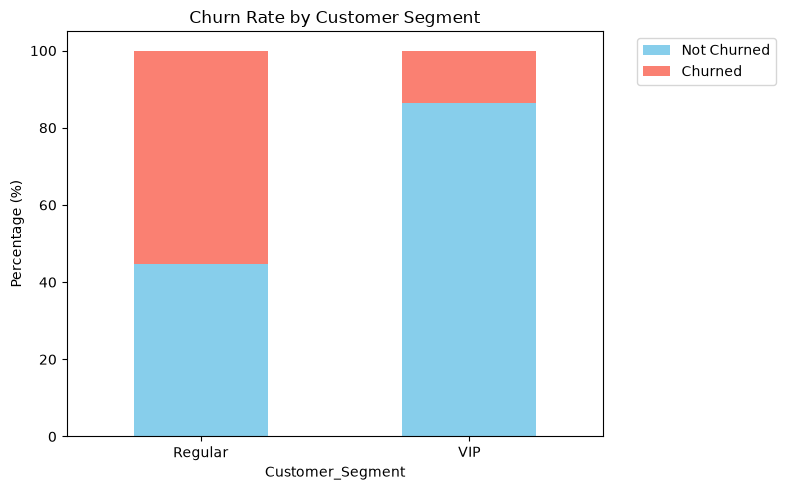

In [13]:
segment_pct.plot(kind='bar', stacked=True, figsize=(8, 5), color=['skyblue', 'salmon'])
plt.title('Churn Rate by Customer Segment')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=0)
plt.legend(['Not Churned', 'Churned'], bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

2. Socho: agar imbalance ratio 1.5:1 hota (halka imbalance) instead of jo tumhe mila, kya tab bhi SMOTE/class_weight zaroori hota? (Hint: general rule — 3:1 se kam imbalance ko kabhi kabhi "mild" maana jaata hai, jahan simple models bhi theek kaam kar lete hain)

Agar ratio 1.5:1 hota (matlab roughly 60% vs 40% ya 57% vs 43%), toh SMOTE ya class_weight='balanced' zaroori nahi hota.

- Kyun?
    - Mild Skew: 3:1 se kam ke ratio ko "mild imbalance" maana jata hai. Standard machine learning models (jaise Logistic Regression ya Random Forest) itne chhote skew ko bina kisi special technique ke bhi achhi tarah handle kar lete hain.

    - Over-correction ka risk: Agar aap 1.5:1 jaise mild imbalance par SMOTE lagate hain, toh yeh unnecessary synthetic data create karega aur model mein noise ya overfitting introduce kar sakta hai, jisse performance actually kharab ho sakti hai.

    - Metrics: Aise cases mein standard Accuracy ya ROC-AUC bhi kaafi reliable hote hain, jabki extreme imbalance (9:1 ya 85:15 jaise) mein Precision, Recall, aur F1-Score hi asli picture dikhate hain.